In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 3.0.5
NumPy: 2.4.6


In [2]:
df = pd.read_csv("../data/raw/istanbul_apartment_prices_2026.csv")

df.head()

,listing_id,price,price_per_sqm,district,neighborhood,rooms,halls,total_rooms,gross_sqm,net_sqm,...,usage_status,is_in_complex,complex_name,orientation,maintenance_fee,credit_eligible,deed_status,exchange,last_updated,scraped_at
0,54895-1121,15900000,165625.00,Adalar,Maden,3,1,4,138.0,96.0,...,Vacant,0,NaN,"North, South, East, West",2500.0,Not Eligible,Land Title,No,2026-03-11,2026-03-14T20:38:29
1,54895-1103,40000000,266666.67,Adalar,Nizam,4,1,5,199.0,150.0,...,Vacant,1,NaN,"North, South, East, West",10000.0,Eligible,Construction Easement,No,2026-03-05,2026-03-14T20:38:36
2,54895-1148,17850000,220370.37,Adalar,Nizam,2,1,3,107.0,81.0,...,Vacant,0,NaN,"North, East, West",1000.0,Eligible,Condominium Title,No,2026-03-05,2026-03-14T20:38:47
3,12854-258,16000000,81632.65,Adalar,Heybeliada,3,1,4,200.0,196.0,...,Owner-occupied,0,NaN,"North, West",NaN,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:38:56
4,121334-99,14000000,96551.72,Adalar,Nizam,4,1,5,160.0,145.0,...,Vacant,0,NaN,NaN,400.0,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:39:04


In [3]:
df.shape

(24767, 30)

In [4]:
df.columns.tolist()

['listing_id',
 'price',
 'price_per_sqm',
 'district',
 'neighborhood',
 'rooms',
 'halls',
 'total_rooms',
 'gross_sqm',
 'net_sqm',
 'floor',
 'floor_category',
 'total_floors',
 'building_age',
 'building_type',
 'building_condition',
 'heating_type',
 'fuel_type',
 'bathroom_count',
 'furnished',
 'usage_status',
 'is_in_complex',
 'complex_name',
 'orientation',
 'maintenance_fee',
 'credit_eligible',
 'deed_status',
 'exchange',
 'last_updated',
 'scraped_at']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24767 entries, 0 to 24766
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          24767 non-null  str    
 1   price               24767 non-null  int64  
 2   price_per_sqm       24767 non-null  float64
 3   district            24767 non-null  str    
 4   neighborhood        24767 non-null  str    
 5   rooms               24767 non-null  int64  
 6   halls               24767 non-null  int64  
 7   total_rooms         24767 non-null  int64  
 8   gross_sqm           24767 non-null  float64
 9   net_sqm             24767 non-null  float64
 10  floor               22850 non-null  float64
 11  floor_category      7395 non-null   str    
 12  total_floors        24766 non-null  float64
 13  building_age        24767 non-null  int64  
 14  building_type       10206 non-null  str    
 15  building_condition  10920 non-null  str    
 16  heating_type   

In [6]:
df.isnull().sum().sort_values(ascending=False)

complex_name          21014
floor_category        17372
maintenance_fee       15765
building_type         14561
fuel_type             13853
building_condition    13847
last_updated          11893
orientation            5316
floor                  1917
exchange               1597
furnished              1078
usage_status            634
bathroom_count          235
credit_eligible           7
deed_status               1
total_floors              1
gross_sqm                 0
total_rooms               0
building_age              0
district                  0
neighborhood              0
rooms                     0
price                     0
listing_id                0
price_per_sqm             0
net_sqm                   0
halls                     0
heating_type              0
is_in_complex             0
scraped_at                0
dtype: int64

In [7]:
df.isnull()

,listing_id,price,price_per_sqm,district,neighborhood,rooms,halls,total_rooms,gross_sqm,net_sqm,...,usage_status,is_in_complex,complex_name,orientation,maintenance_fee,credit_eligible,deed_status,exchange,last_updated,scraped_at
0,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24762,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,True,False
24763,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False
24764,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
24765,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [8]:
df.sum()

listing_id            54895-112154895-110354895-114812854-258121334-...
price                                                      332616986969
price_per_sqm                                              3284325423.4
district              AdalarAdalarAdalarAdalarAdalarAdalarAdalarAdal...
neighborhood          MadenNizamNizamHeybeliadaNizamHeybeliadaMadenM...
rooms                                                             63830
halls                                                             26961
total_rooms                                                       90791
gross_sqm                                                     3128519.0
net_sqm                                                       2662242.0
floor                                                           63999.0
floor_category        Garden FloorTop FloorGarden FloorGarden FloorT...
total_floors                                                   164030.0
building_age                                                    

In [9]:
df.sum()

listing_id            54895-112154895-110354895-114812854-258121334-...
price                                                      332616986969
price_per_sqm                                              3284325423.4
district              AdalarAdalarAdalarAdalarAdalarAdalarAdalarAdal...
neighborhood          MadenNizamNizamHeybeliadaNizamHeybeliadaMadenM...
rooms                                                             63830
halls                                                             26961
total_rooms                                                       90791
gross_sqm                                                     3128519.0
net_sqm                                                       2662242.0
floor                                                           63999.0
floor_category        Garden FloorTop FloorGarden FloorGarden FloorT...
total_floors                                                   164030.0
building_age                                                    

In [10]:
df.sort_values(ascending=False)

TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

In [ ]:
df.duplicated().sum()

In [ ]:
df["price"].describe()

In [ ]:
df.loc[df["price"].idxmin()]

In [ ]:
df["district"].nunique()

In [ ]:
df["district"].value_counts()

In [ ]:
df["neighborhood"].nunique()

In [ ]:
df.loc[df["price"].idxmax()]

In [11]:
df.nlargest(
    10,
    "price"
)[
    [
        "price",
        "district",
        "neighborhood",
        "net_sqm",
        "gross_sqm",
        "rooms",
        "building_age"
    ]
]


,price,district,neighborhood,net_sqm,gross_sqm,rooms,building_age
5215,11500000000,Bayrampaşa,Kartaltepe,190.0,191.0,5,0
14561,10500000000,Kağıthane,Yahya Kemal,73.0,92.0,2,3
3566,8950000000,Bakırköy,Zuhuratbaba,75.0,85.0,2,0
11705,8750000000,Fatih,Şehremini,145.0,150.0,3,35
20285,5189000000,Şişli,Kuştepe,150.0,160.0,3,8
12151,4500000000,Gaziosmanpaşa,Merkez,90.0,95.0,2,20
12453,4200000000,Güngören,Merkez,120.0,140.0,3,21
16996,3825000000,Maltepe,Zümrütevler,60.0,70.0,1,0
13791,3550000000,Kağıthane,Nurtepe,120.0,130.0,2,11
6159,460000000,Beykoz,Çubuklu,210.0,240.0,2,31


In [12]:
df.nsmallest(
    10,
    "price"
)[
    [
        "price",
        "district",
        "neighborhood",
        "net_sqm",
        "gross_sqm",
        "rooms",
        "building_age"
    ]
]

,price,district,neighborhood,net_sqm,gross_sqm,rooms,building_age
18921,24000,Sancaktepe,Merve,82.0,94.0,2,4
17924,26500,Pendik,Yenişehir,70.0,80.0,2,26
9140,30000,Esenler,Fevzi Çakmak,100.0,120.0,3,0
14293,35000,Kağıthane,Çeliktepe,77.0,90.0,2,1
17703,38000,Pendik,Dumlupınar,85.0,110.0,3,0
18612,38000,Sancaktepe,Sarıgazi,80.0,90.0,2,2
2690,40000,Bahçelievler,Zafer,90.0,100.0,2,6
15491,50000,Küçükçekmece,Cennet,130.0,150.0,3,21
2740,65000,Bahçelievler,Bahçelievler,130.0,140.0,3,26
19914,460000,Silivri,Yeni,85.0,100.0,2,0


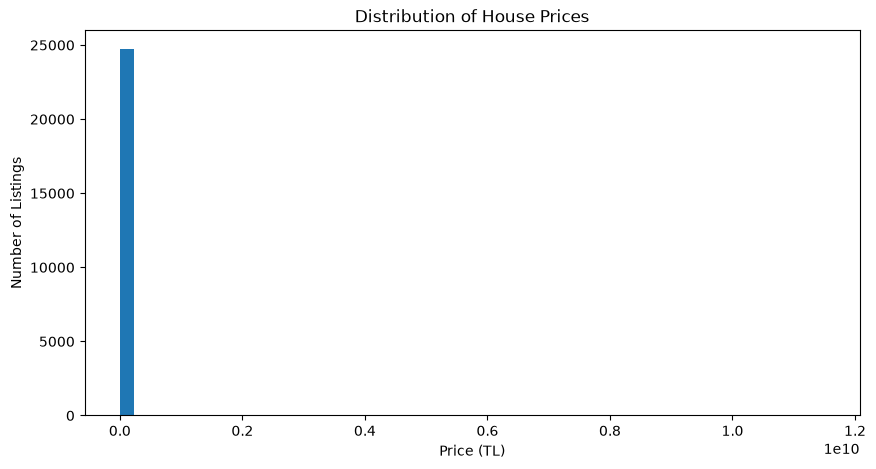

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(df["price"], bins=50)

plt.title("Distribution of House Prices")
plt.xlabel("Price (TL)")
plt.ylabel("Number of Listings")

plt.show()

In [14]:
df["price"].quantile([
    0.001,
    0.005,
    0.01,
    0.05,
    0.50,
    0.95,
    0.99,
    0.995,
    0.999
])

0.001    9.500000e+05
0.005    1.375000e+06
0.010    1.625000e+06
0.050    2.500000e+06
0.500    6.750000e+06
0.950    3.200000e+07
0.990    7.600000e+07
0.995    1.050000e+08
0.999    2.023400e+08
Name: price, dtype: float64

In [15]:
print("1 milyon TL altı:",
      (df["price"] < 1_000_000).sum())

print("100 milyon TL üstü:",
      (df["price"] > 100_000_000).sum())

print("500 milyon TL üstü:",
      (df["price"] > 500_000_000).sum())

print("1 milyar TL üstü:",
      (df["price"] > 1_000_000_000).sum())

1 milyon TL altı: 30
100 milyon TL üstü: 127
500 milyon TL üstü: 9
1 milyar TL üstü: 9


In [16]:
extreme = df[df["price"] > 500_000_000].copy()

extreme[
    [
        "price",
        "price_per_sqm",
        "district",
        "neighborhood",
        "net_sqm",
        "gross_sqm",
        "rooms"
    ]
]

,price,price_per_sqm,district,neighborhood,net_sqm,gross_sqm,rooms
3566,8950000000,1.193333e+08,Bakırköy,Zuhuratbaba,75.0,85.0,2
5215,11500000000,6.052632e+07,Bayrampaşa,Kartaltepe,190.0,191.0,5
11705,8750000000,6.034483e+07,Fatih,Şehremini,145.0,150.0,3
12151,4500000000,5.000000e+07,Gaziosmanpaşa,Merkez,90.0,95.0,2
12453,4200000000,3.500000e+07,Güngören,Merkez,120.0,140.0,3
13791,3550000000,2.958333e+07,Kağıthane,Nurtepe,120.0,130.0,2
14561,10500000000,1.438356e+08,Kağıthane,Yahya Kemal,73.0,92.0,2
16996,3825000000,6.375000e+07,Maltepe,Zümrütevler,60.0,70.0,1
20285,5189000000,3.459333e+07,Şişli,Kuştepe,150.0,160.0,3


In [17]:
extreme["price_if_divided_1000"] = extreme["price"] / 1000

extreme[
    [
        "price",
        "price_if_divided_1000",
        "district",
        "neighborhood",
        "net_sqm"
    ]
]

,price,price_if_divided_1000,district,neighborhood,net_sqm
3566,8950000000,8950000.0,Bakırköy,Zuhuratbaba,75.0
5215,11500000000,11500000.0,Bayrampaşa,Kartaltepe,190.0
11705,8750000000,8750000.0,Fatih,Şehremini,145.0
12151,4500000000,4500000.0,Gaziosmanpaşa,Merkez,90.0
12453,4200000000,4200000.0,Güngören,Merkez,120.0
13791,3550000000,3550000.0,Kağıthane,Nurtepe,120.0
14561,10500000000,10500000.0,Kağıthane,Yahya Kemal,73.0
16996,3825000000,3825000.0,Maltepe,Zümrütevler,60.0
20285,5189000000,5189000.0,Şişli,Kuştepe,150.0


In [18]:
low_price = df[df["price"] < 1_000_000]

low_price[
    [
        "price",
        "price_per_sqm",
        "district",
        "neighborhood",
        "net_sqm",
        "gross_sqm",
        "rooms"
    ]
].sort_values("price")

,price,price_per_sqm,district,neighborhood,net_sqm,gross_sqm,rooms
18921,24000,292.68,Sancaktepe,Merve,82.0,94.0,2
17924,26500,378.57,Pendik,Yenişehir,70.0,80.0,2
9140,30000,300.00,Esenler,Fevzi Çakmak,100.0,120.0,3
14293,35000,454.55,Kağıthane,Çeliktepe,77.0,90.0,2
18612,38000,475.00,Sancaktepe,Sarıgazi,80.0,90.0,2
17703,38000,447.06,Pendik,Dumlupınar,85.0,110.0,3
2690,40000,444.44,Bahçelievler,Zafer,90.0,100.0,2
15491,50000,384.62,Küçükçekmece,Cennet,130.0,150.0,3
2740,65000,500.00,Bahçelievler,Bahçelievler,130.0,140.0,3
19914,460000,5411.76,Silivri,Yeni,85.0,100.0,2


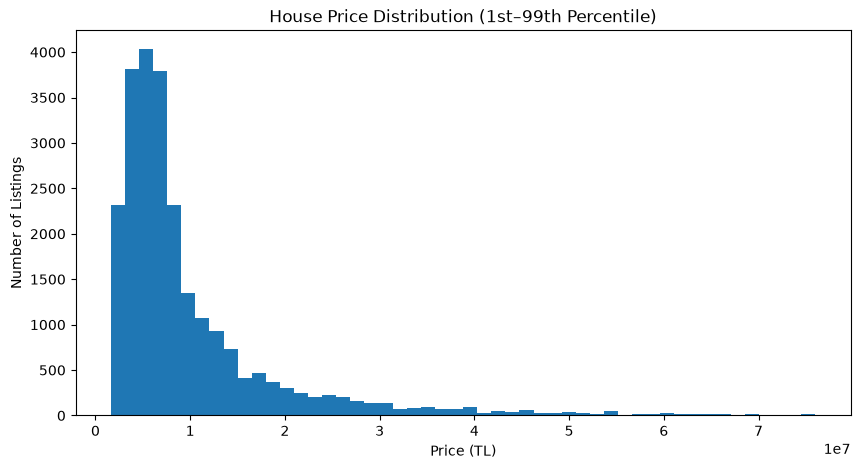

In [19]:
lower = df["price"].quantile(0.01)
upper = df["price"].quantile(0.99)

price_visual = df[
    df["price"].between(lower, upper)
]

plt.figure(figsize=(10, 5))

plt.hist(price_visual["price"], bins=50)

plt.title("House Price Distribution (1st–99th Percentile)")
plt.xlabel("Price (TL)")
plt.ylabel("Number of Listings")

plt.show()

In [20]:
price_visual

,listing_id,price,price_per_sqm,district,neighborhood,rooms,halls,total_rooms,gross_sqm,net_sqm,...,usage_status,is_in_complex,complex_name,orientation,maintenance_fee,credit_eligible,deed_status,exchange,last_updated,scraped_at
0,54895-1121,15900000,165625.00,Adalar,Maden,3,1,4,138.0,96.0,...,Vacant,0,NaN,"North, South, East, West",2500.0,Not Eligible,Land Title,No,2026-03-11,2026-03-14T20:38:29
1,54895-1103,40000000,266666.67,Adalar,Nizam,4,1,5,199.0,150.0,...,Vacant,1,NaN,"North, South, East, West",10000.0,Eligible,Construction Easement,No,2026-03-05,2026-03-14T20:38:36
2,54895-1148,17850000,220370.37,Adalar,Nizam,2,1,3,107.0,81.0,...,Vacant,0,NaN,"North, East, West",1000.0,Eligible,Condominium Title,No,2026-03-05,2026-03-14T20:38:47
3,12854-258,16000000,81632.65,Adalar,Heybeliada,3,1,4,200.0,196.0,...,Owner-occupied,0,NaN,"North, West",NaN,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:38:56
4,121334-99,14000000,96551.72,Adalar,Nizam,4,1,5,160.0,145.0,...,Vacant,0,NaN,NaN,400.0,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:39:04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24762,3448-15270,23500000,183593.75,Zeytinburnu,Seyitnizam,3,1,4,185.0,128.0,...,Vacant,0,NaN,NaN,NaN,Eligible,No Title Deed,No,NaN,2026-03-19T04:49:03
24763,3448-15034,42500000,293103.45,Zeytinburnu,Kazlıçeşme,3,1,4,195.0,145.0,...,Tenant-occupied,1,Büyükyalı İstanbul,NaN,NaN,Eligible,Condominium Title,No,NaN,2026-03-19T04:49:14
24764,144355-735,7000000,194444.44,Zeytinburnu,Veliefendi,1,1,2,52.0,36.0,...,Vacant,1,Mega Garden Park,"South, East",NaN,Eligible,Construction Easement,No,NaN,2026-03-19T04:49:25
24765,144355-444,12000000,179104.48,Zeytinburnu,Veliefendi,2,1,3,97.0,67.0,...,Vacant,1,Mega Garden Park,South,NaN,Eligible,Construction Easement,Yes,NaN,2026-03-19T04:49:39


In [21]:
df["price_per_sqm"].describe(
    percentiles=[0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
)


count    2.476700e+04
mean     1.326089e+05
std      1.967747e+06
min      2.926800e+02
0.1%     1.105868e+04
1%       1.897469e+04
5%       2.821429e+04
50%      7.250000e+04
95%      2.490526e+05
99%      4.363636e+05
99.9%    7.930141e+05
max      1.600000e+08
Name: price_per_sqm, dtype: float64

In [22]:
df[
    ["price", "price_per_sqm", "net_sqm"]
].head(10).assign(
    calculated_price_per_sqm=lambda x: x["price"] / x["net_sqm"]
)

,price,price_per_sqm,net_sqm,calculated_price_per_sqm
0,15900000,165625.00,96.0,165625.000000
1,40000000,266666.67,150.0,266666.666667
2,17850000,220370.37,81.0,220370.370370
3,16000000,81632.65,196.0,81632.653061
4,14000000,96551.72,145.0,96551.724138
5,12000000,120000.00,100.0,120000.000000
6,21900000,146000.00,150.0,146000.000000
7,6500000,135416.67,48.0,135416.666667
8,18500000,115625.00,160.0,115625.000000
9,12100000,89629.63,135.0,89629.629630


In [23]:
(df["rooms"] + df["halls"] != df["total_rooms"]).sum()

np.int64(0)

In [24]:
(df["net_sqm"] > df["gross_sqm"]).sum()

np.int64(5)

In [25]:
df[df["net_sqm"] > df["gross_sqm"]][
    [
        "district",
        "neighborhood",
        "gross_sqm",
        "net_sqm",
        "price"
    ]
].head(20)

,district,neighborhood,gross_sqm,net_sqm,price
5945,Beşiktaş,Kuruçeşme,1.0,900.0,339750000
6131,Beşiktaş,Kuruçeşme,1.0,900.0,339750000
19301,Sarıyer,Yeniköy,1.0,800.0,325000000
23926,Üsküdar,Küçüksu,2.0,160.0,14800000
24729,Zeytinburnu,Merkezefendi,1.0,110.0,15200000


In [26]:
df = pd.read_csv(
    "../data/raw/istanbul_apartment_prices_2026.csv"
)

In [27]:
import os

print(os.getcwd())

C:\Users\Oyku\Desktop\EstateAI\notebooks


In [28]:
import os

print(os.listdir())

['.ipynb_checkpoints', '01_data_exploration.ipynb', '02_data_cleaning.ipynb', '03_feature_engineering.ipynb', '04_feature_selection.ipynb', '05_model_training.ipynb', 'catboost_info']


In [29]:
import os

print(os.listdir(".."))

['.venv', 'app', 'backend', 'data', 'estate-ai', 'frontend', 'models', 'notebooks', 'requirements.txt', 'src']


In [30]:
print(os.listdir("../data"))

['processed', 'raw']
